# ov.synbio IV — advanced SOTA: mRNA design, de-novo binders, prime editing

This tutorial tours the **advanced-SOTA** layer of `ov.synbio` — real, published state-of-the-art models wired behind the same `method=` convention. Each shows a **baseline ↔ SOTA** comparison so you can see what the heavy model buys you.

- **mRNA therapeutics** — LinearDesign (joint codon+structure optimisation)
- **RNA design** — inverse folding, siRNA, antisense oligos
- **Genome editing** — prime editing (pegRNA), CRISPRi/a, Cas13
- **Metabolic** — dynamic FBA, minimal cut sets, retrobiosynthesis
- **De-novo binder design** — RFdiffusion → ProteinMPNN → Boltz-2

Heavy backends (LinearDesign, Boltz-2, RFdiffusion) run from their own environments via subprocess; `import omicverse` needs none of them. `pip install 'omicverse[synbio]'`.

In [1]:
import omicverse as ov

ov.plot_set()
print('omicverse', ov.__version__)

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.

omicverse 2.2.1rc1


## 1 — mRNA therapeutics design (LinearDesign)

Designing an mRNA is not just codon optimisation: secondary-structure stability (MFE) and codon adaptation (CAI) trade off. `mrna_design(method='lineardesign')` runs the real **LinearDesign** (Zhang *et al.*, *Nature* 2023) — a lattice dynamic program that finds the jointly MFE/CAI-optimal mRNA. `lambda` tunes the balance.

In [2]:
protein = 'MGSSHHHHHHSSGLVPRGSHMKIEEGKLVIWINGDKGYNGLAEVGKKFEKDTGIKVTVEHPDKLEEKFPQVAATGDGPDIIFWAHDRFGG'
# baseline (DNAchisel codon-opt) vs LinearDesign at two lambdas
base = ov.synbio.mrna_design(protein, method='baseline')
ld0  = ov.synbio.mrna_design(protein, method='lineardesign', lam=0.0)
ld3  = ov.synbio.mrna_design(protein, method='lineardesign', lam=3.0)
print(base); print(ld0); print(ld3)

MRNADesign(len=270nt, MFE=-94.0 kcal/mol, CAI=0.648, baseline)
MRNADesign(len=270nt, MFE=-158.4 kcal/mol, CAI=0.817, lineardesign)
MRNADesign(len=270nt, MFE=-142.2 kcal/mol, CAI=0.945, lineardesign)


LinearDesign **dominates the baseline on both axes** — a more negative folding energy (stabler mRNA) *and* a higher CAI. `lambda=0` is the most-structured; raising it trades structure for codon optimality:

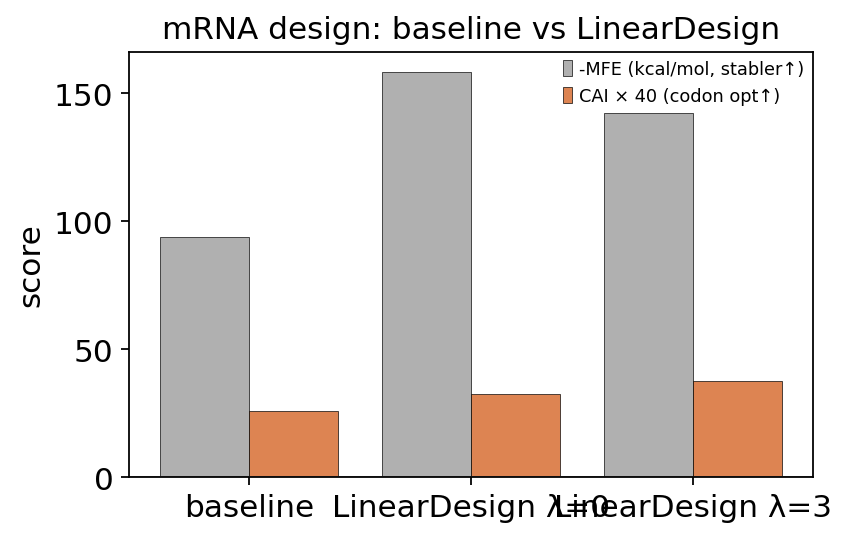

In [3]:
labels = ['baseline', 'LinearDesign λ=0', 'LinearDesign λ=3']
ov.synbio.plot_method_comparison(labels,
    {'-MFE (kcal/mol, stabler↑)': [-base.mfe, -ld0.mfe, -ld3.mfe],
     'CAI × 40 (codon opt↑)':     [40*base.cai, 40*ld0.cai, 40*ld3.cai]},
    ylabel='score', title='mRNA design: baseline vs LinearDesign')
None

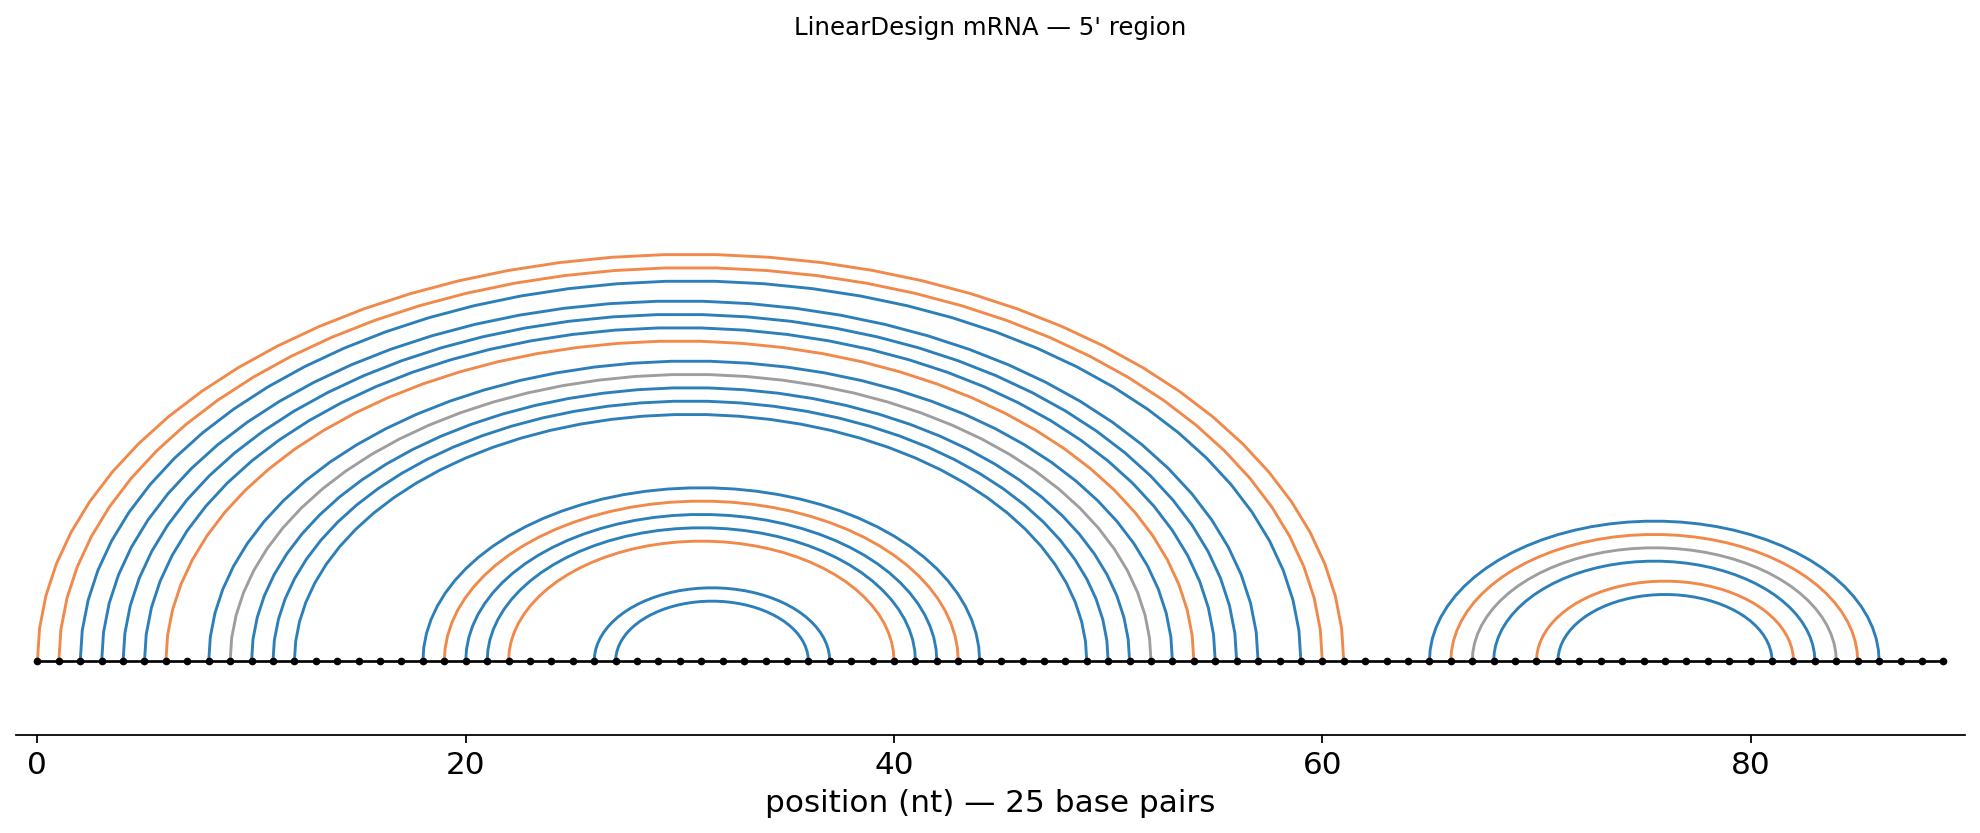

In [4]:
# the secondary structure LinearDesign optimises — fold the designed mRNA and draw it
s = ov.synbio.rna_fold(ld3.mrna[:90])
ov.synbio.plot_rna_structure(s.sequence, s.structure, title='LinearDesign mRNA — 5\' region')
None

## 2 — RNA design: inverse folding, siRNA, antisense

`rna_inverse_design` solves the *inverse* folding problem — find a sequence that folds into a **target** structure (riboswitches, aptamers, thermometers).

In [5]:
target = '((((((((....))))))))'    # a hairpin
designs = ov.synbio.rna_inverse_design(target, n=3)
for d in designs:
    print(f'{d.sequence}  ->  {d.structure}  (dist={d.distance}, mfe={d.mfe:.1f})')

GCGCGCGCGCGCGCGCGCGU  ->  ((((((((....))))))))  (dist=0, mfe=-15.3)
GGGCGCGCGCGCGCGCGCCU  ->  ((((((((....))))))))  (dist=0, mfe=-15.8)
GCGCGCGCGCGCGCGCGUGC  ->  ((((((((....))))))))  (dist=0, mfe=-14.8)


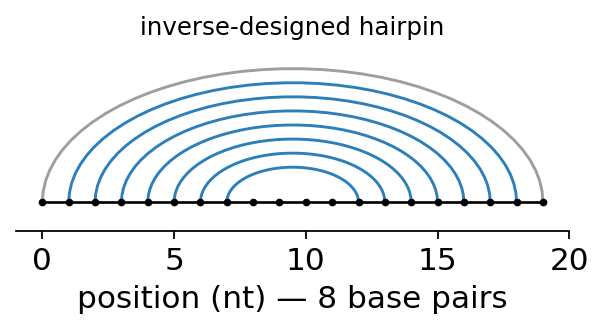

In [6]:
# the designed sequence folds exactly into the requested hairpin
ov.synbio.plot_rna_structure(designs[0].sequence, designs[0].structure,
                             title='inverse-designed hairpin')
None

`sirna_design` ranks 19-mer siRNAs by the published Reynolds-2004 rules; `aso_design` designs antisense gapmers scored by target accessibility, Tm and liability motifs:

In [7]:
mrna = ('ATGGGGAAGGTGAAGGTCGGAGTCAACGGATTTGGTCGTATTGGGCGCCTGGTCACCAGGGCTGCTTTTAACTCTGGT'
        'AAAGTGGATATTGTTGCCATCAATGACCCCTTCATTGACCTCAACTACATGGTTTACATGTTCCAATATGATTCCACCC')
si = ov.synbio.sirna_design(mrna, n=3, method='reynolds')
for s in si: print('siRNA', s.antisense, 'score', s.score)
aso = ov.synbio.aso_design(mrna, length=18, n=2)
for a in aso: print('ASO', a.aso, f'Tm={a.tm:.0f} open={a.accessibility:.1f}')

siRNA UUGAUGGCAACAAUAUCCAUU score 6
siRNA AUUGAUGGCAACAAUAUCCUU score 6
siRNA UCAUUGAUGGCAACAAUAUUU score 6


ASO TCCACTTTACCAGAGTTA Tm=43 open=3.9
ASO TTACCAGAGTTAAAAGCA Tm=42 open=3.9


**Where do they bind?** `plot_binding_sites` maps the designed siRNAs and antisense oligos onto the target transcript:

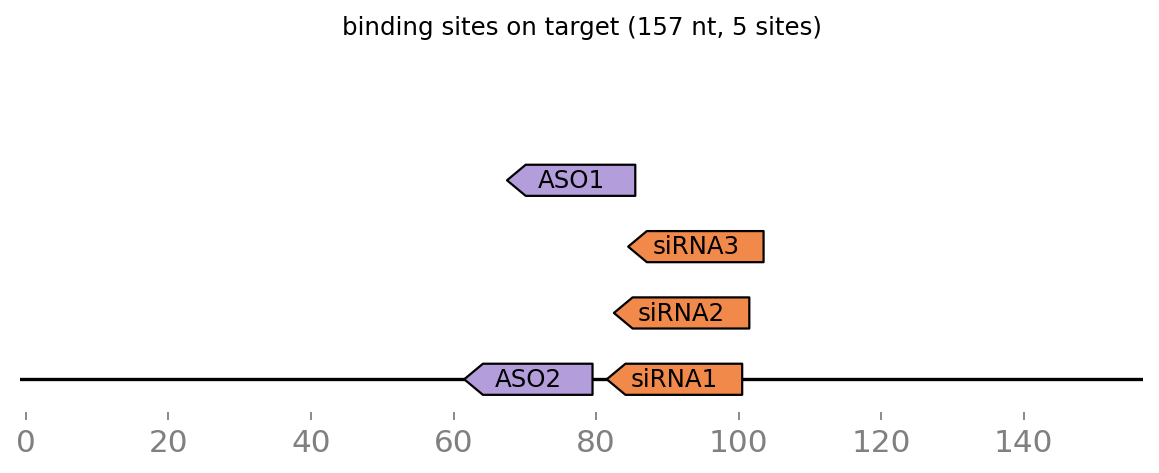

In [3]:
# where the siRNAs and antisense oligos bind on the transcript
ov.synbio.plot_binding_sites(mrna, sirnas=si, asos=aso)
None

## 3 — Prime editing (pegRNA)

`prime_editing_design` designs a **pegRNA** (spacer + RT template + primer-binding site) and a PE3 nicking guide for a desired edit. `method='baseline'` uses transparent Anzalone-2019 rules; `method='primedesign'` runs the vendored **PrimeDesign** (Pinello lab). Here we install a point mutation:

In [8]:
locus = 'ATGTGCTGTGATGGTATGCCGGCGTAGTAATCGTAGCACGTTGCACTGACCATCGGACTGACATGGCTAGATTTTGGGGCC'
ep = 17
pb = ov.synbio.prime_editing_design(locus, edit_pos=ep, ref=locus[ep], alt='A', method='baseline')[0]
pd = ov.synbio.prime_editing_design(locus, edit_pos=ep, ref=locus[ep], alt='A', method='primedesign')[0]
print('baseline    :', pb.spacer, '| ext', pb.extension_3p)
print('PrimeDesign :', pd.spacer, '| ext', pd.extension_3p, '| PE3', pd.pe3_nick['spacer'] if pd.pe3_nick else None)

baseline    : ACGTGCTACGATTACTACGC | ext GTGATGGTATACCGGCGTAGTAATCGTAGC
PrimeDesign : ACGTGCTACGATTACTACGC | ext ATGTGCTGTGATGGTATACCGGCGTAGTAATCGTAGCAC | PE3 TAGCACGTTGCACTGACCAT


**Visualise the pegRNA.** `plot_pegrna` maps the PrimeDesign result onto the target locus — the protospacer, the Cas9 nick, the PBS and RT template (which carries the edit), the edit position, and the PE3 secondary nick.

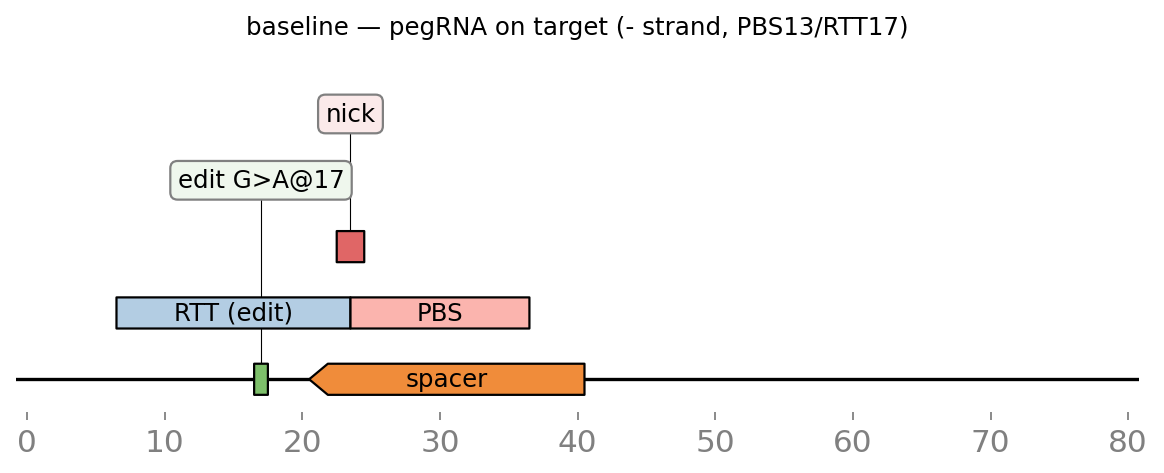

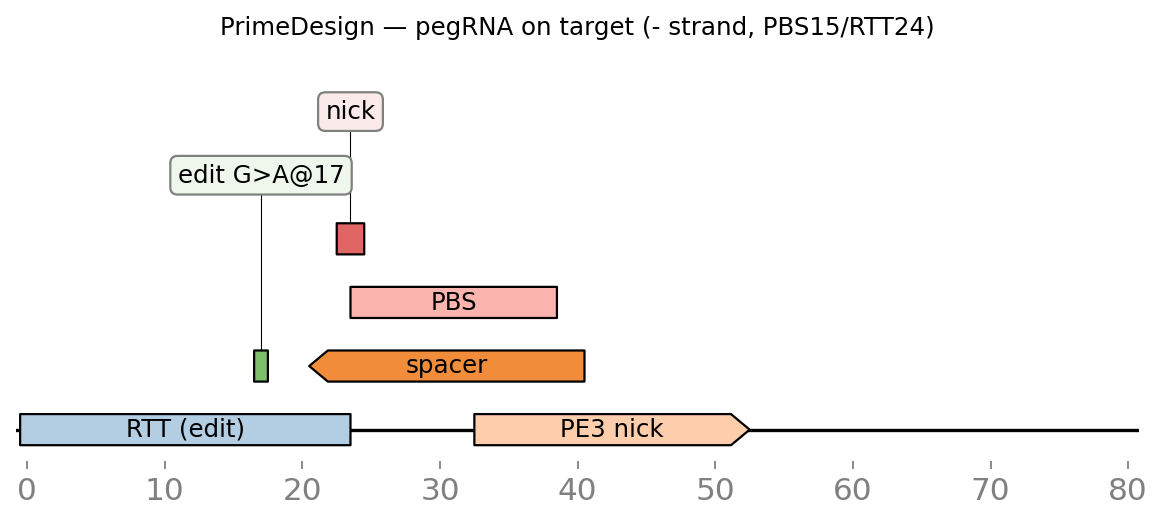

In [3]:
# map both pegRNA designs onto the target locus — baseline vs PrimeDesign
ov.synbio.plot_pegrna(locus, pb, edit_pos=ep, label='baseline')
ov.synbio.plot_pegrna(locus, pd, edit_pos=ep, label='PrimeDesign')
None

Both pick the **same spacer / nick** — the transparent baseline agrees with the reference tool, which adds ranged PBS/RTT and PE3b ngRNAs. `crispr_regulation` and `design_cas13_guides` cover CRISPRi/a and RNA-targeting Cas13:

In [3]:
promoter = ('GCATGCATGC'*4) + 'ATGGCACGTGGATCCGGACATGCACCGGTTAACGGGACCGGT'*3
mrna_u = mrna.replace('T', 'U')
gi = ov.synbio.crispr_regulation(promoter, tss=50, mode='crispri')
print('CRISPRi best:', gi[0].spacer, 'TSS%+d' % gi[0].tss_offset)
c13 = ov.synbio.design_cas13_guides(mrna_u, n=4)
print('Cas13 crRNA :', c13[0].spacer, 'PFS', c13[0].pfs)

CRISPRi best: TCCGGACATGCACCGGTTAA TSS+86


Cas13 crRNA : AUGGUUUACAUGUUCCAAUAUGAUUCCA PFS C


The same map works for **guides** — CRISPRi guides along the promoter (relative to the TSS) and Cas13 crRNAs along the transcript:

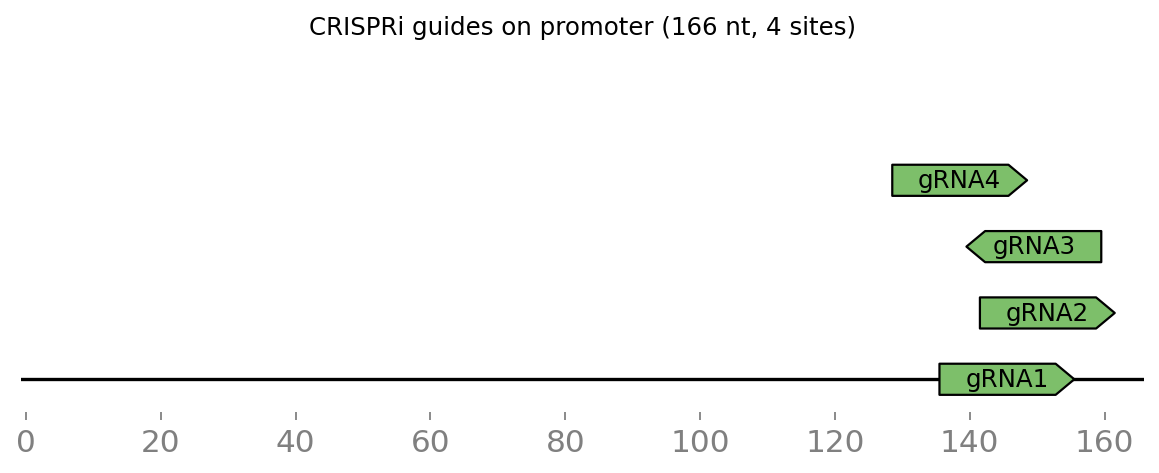

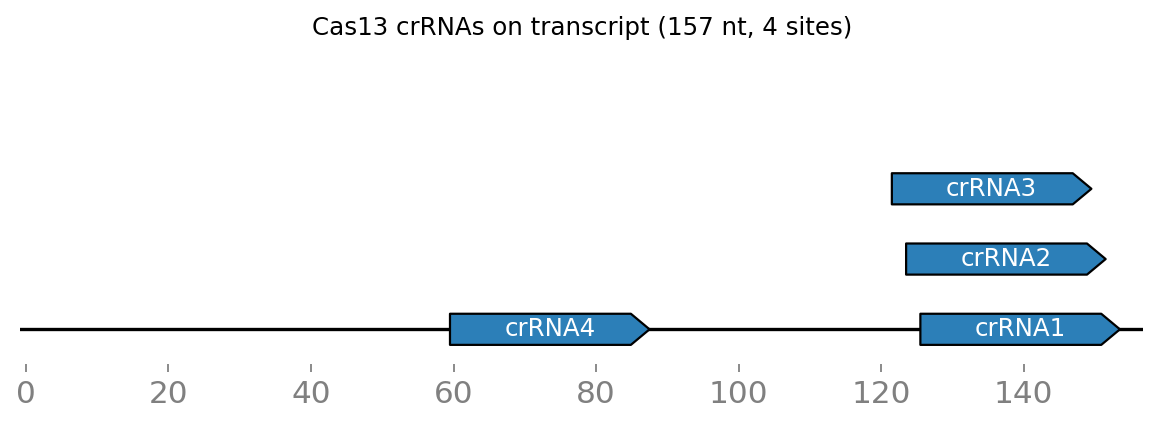

In [4]:
# guide binding sites — CRISPRi on the promoter, Cas13 on the transcript
ov.synbio.plot_binding_sites(promoter, guides=gi[:4], title='CRISPRi guides on promoter')
ov.synbio.plot_binding_sites(mrna_u, cas13_guides=c13, title='Cas13 crRNAs on transcript')
None

## 4 — Metabolic: dynamic FBA, minimal cut sets, retrobiosynthesis

`dynamic_fba` turns a genome-scale model into a **batch-fermentation time course** (Mahadevan 2002): Michaelis–Menten uptake sets the FBA bound each step, and biomass/substrate/product integrate forward.

INFO:cobra.io.web.load:Attempting to fetch 'e_coli_core' from the Cobrapy repository.


INFO:cobra.io.web.load:Attempting to fetch 'e_coli_core' from the BiGG Models repository.


Output()

INFO:httpx:HTTP Request: GET http://bigg.ucsd.edu/static/models/e_coli_core.xml.gz "HTTP/1.1 200 OK"


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


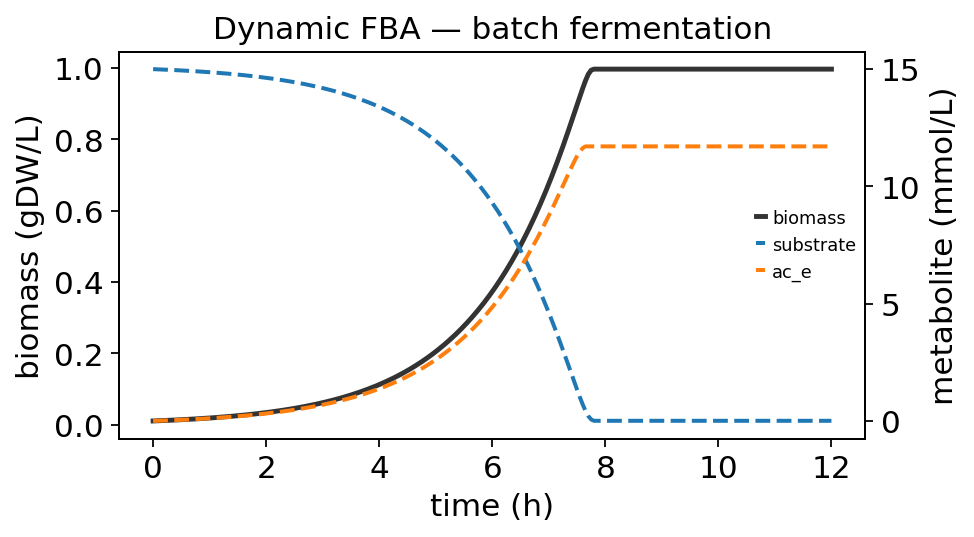

In [10]:
m = ov.synbio.load_gem('e_coli_core')
m.reactions.EX_o2_e.lower_bound = -12          # O2-limited -> acetate overflow
df = ov.synbio.dynamic_fba(m, 'EX_glc__D_e', biomass_0=0.01, substrate_0=15,
                           t_end=12, products=['EX_ac_e'])
ov.synbio.plot_dynamic_fba(df)
None

`strain_design(method='mcs')` computes **minimal cut sets** that growth-couple a product; `retro_biosynthesis` proposes novel enzymatic steps to a target molecule via reaction rules:

In [11]:
res = ov.synbio.strain_design(m, 'EX_succ_e', method='mcs', max_knockouts=2)
print('succinate cut sets:', list(res.knockout['knockouts'].head(3)))
routes = ov.synbio.retro_biosynthesis('CC(=O)C(=O)O')   # pyruvate
print('pyruvate precursors:', routes[0].steps[0].rule, '->', routes[0].precursors)

succinate cut sets: [['CO2t', 'PGI'], ['EX_co2_e', 'PGI']]


pyruvate precursors: aldehyde_oxidation -> ['CC(=O)C=O']


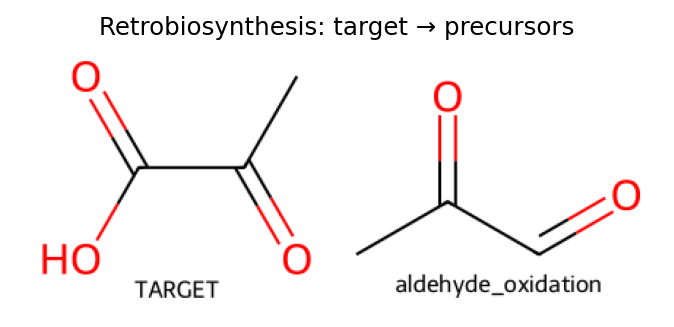

In [12]:
# draw the retrobiosynthetic routes as molecule structures
ov.synbio.plot_retro_routes(routes, n=3)
None

## 5 — De-novo binder design (RFdiffusion → ProteinMPNN → Boltz-2)

The flagship protein-design workflow. `denovo_binder` (1) diffuses binder backbones docked on the target's hotspots with **RFdiffusion**, (2) designs the binder sequence with **ProteinMPNN** (target fixed), and (3) validates each design by folding it. Here we design a binder against the insulin receptor:

In [13]:
# RFdiffusion ships this target (insulin receptor) in its examples
import os
target = os.path.join(os.environ['OMICOS_SYNBIO_WEIGHTS'],
                      'RFdiffusion/examples/input_pdbs/insulin_target.pdb')
designs = ov.synbio.denovo_binder(target, hotspot_res=['A59','A83','A91'],
                                  binder_length=70, num_backbones=1, num_seqs=1,
                                  validate='esmfold')
for d in designs:
    print(d)
    print('  binder:', d.sequence)

/scratch/users/steorra/.omicverse_synbio_weights/RFdiffusion/rfdiffusion/util.py:253: UserWarning: Using torch.cross without specifying the dim arg is deprecated.
Please either pass the dim explicitly or simply use torch.linalg.cross.
The default value of dim will change to agree with that of linalg.cross in a future release. (Triggered internally at /pytorch/aten/src/ATen/native/Cross.cpp:62.)
  Z = torch.cross(Xn, Yn)


/scratch/users/steorra/.omicverse_synbio_weights/RFdiffusion/rfdiffusion/Track_module.py:236: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @torch.cuda.amp.autocast(enabled=False)


[2026-07-21 05:20:10,146][__main__][INFO] - Found GPU with device_name NVIDIA H100 80GB HBM3. Will run RFdiffusion on NVIDIA H100 80GB HBM3
Reading models from /scratch/users/steorra/.omicverse_synbio_weights/RFdiffusion/models
[2026-07-21 05:20:10,147][rfdiffusion.inference.model_runners][INFO] - Reading checkpoint from /scratch/users/steorra/.omicverse_synbio_weights/RFdiffusion/models/Complex_base_ckpt.pt


This is inf_conf.ckpt_path
/scratch/users/steorra/.omicverse_synbio_weights/RFdiffusion/models/Complex_base_ckpt.pt
Assembling -model, -diffuser and -preprocess configs from checkpoint
USING MODEL CONFIG: self._conf[model][n_extra_block] = 4
USING MODEL CONFIG: self._conf[model][n_main_block] = 32
USING MODEL CONFIG: self._conf[model][n_ref_block] = 4
USING MODEL CONFIG: self._conf[model][d_msa] = 256
USING MODEL CONFIG: self._conf[model][d_msa_full] = 64
USING MODEL CONFIG: self._conf[model][d_pair] = 128
USING MODEL CONFIG: self._conf[model][d_templ] = 64
USING MODEL CONFIG: self._conf[model][n_head_msa] = 8
USING MODEL CONFIG: self._conf[model][n_head_pair] = 4
USING MODEL CONFIG: self._conf[model][n_head_templ] = 4
USING MODEL CONFIG: self._conf[model][d_hidden] = 32
USING MODEL CONFIG: self._conf[model][d_hidden_templ] = 32
USING MODEL CONFIG: self._conf[model][p_drop] = 0.15
USING MODEL CONFIG: self._conf[model][SE3_param_full] = {'num_layers': 1, 'num_channels': 32, 'num_degrees

With this beta schedule (linear schedule, beta_0 = 0.04, beta_T = 0.28), alpha_bar_T = 0.00013696050154976547
[2026-07-21 05:20:51,998][rfdiffusion.inference.model_runners][INFO] - Sequence init: ----------------------------------------------------------------------EVCPGMDIRNNLTRLHELENCSVIEGHLQILLMFKTRPEDFRDLSFPKLIMITDYLLLFRVYGLESLKDLFPNLTVIRGSRLFFNYALVIFEMVHLKELGLYNLMNITRGSVRIEKNNELCYLATIDWSRILDSVEDNHIVLNKDDNEEC


...

[2026-07-21 05:23:19,109][rfdiffusion.inference.utils][INFO] - Sampled motif RMSD: 0.13
[2026-07-21 05:23:19,128][rfdiffusion.inference.model_runners][INFO] - Timestep 2, input to next step: ----------------------------------------------------------------------EVCPGMDIRNNLTRLHELENCSVIEGHLQILLMFKTRPEDFRDLSFPKLIMITDYLLLFRVYGLESLKDLFPNLTVIRGSRLFFNYALVIFEMVHLKELGLYNLMNITRGSVRIEKNNELCYLATIDWSRILDSVEDNHIVLNKDDNEEC


[2026-07-21 05:23:24,690][__main__][INFO] - Finished design in 2.55 minutes


[ov.synbio.predict_structure] device=cuda (NVIDIA H100 80GB HBM3, 79 GB) len=70


Some weights of EsmForProteinFolding were not initialized from the model checkpoint at facebook/esmfold_v1 and are newly initialized: ['esm.contact_head.regression.bias', 'esm.contact_head.regression.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[ov.synbio.predict_structure] done: mean pLDDT=94.4
BinderDesign(len=70, mpnn=0.932, pLDDT=0.94, seq=SETLKAAGYQVKALSYASEA...)
  binder: SETLKAAGYQVKALSYASEAEELAKKNPETKELAEKAKEAAEKAIKSTDAEEAKKYAEEAERLLKEMKEA


In [14]:
# fold the designed binder and view it in interactive 3D (coloured by pLDDT)
pred = ov.synbio.predict_structure(designs[0].sequence)
ov.synbio.view_structure(pred)

[ov.synbio.predict_structure] device=cuda (NVIDIA H100 80GB HBM3, 79 GB) len=70


[ov.synbio.predict_structure] done: mean pLDDT=94.4


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

A single command produced a folded, target-docked mini-binder. `predict_complex` (Boltz-2) can co-fold and score any protein–ligand or protein–protein complex for **binding affinity**:

In [15]:
gb1 = 'MTYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDDATKTFTVTE'
r = ov.synbio.predict_complex([{'id':'A','protein':gb1}, {'id':'B','smiles':'c1ccccc1'}],
                              affinity_binder='B')
print(f'pLDDT={r.plddt:.2f}  pTM={r.ptm:.2f}  affinity p_bind={r.affinity["binder_probability"]:.2f}')

pLDDT=0.91  pTM=0.94  affinity p_bind=0.04


## Summary

Every advanced method follows the omicverse convention — one function, SOTA behind `method=`:

| Task | baseline | SOTA (`method=`) |
|---|---|---|
| mRNA design | DNAchisel codon-opt | **LinearDesign** (Nature 2023) |
| prime editing | Anzalone rules | **PrimeDesign** |
| complex + affinity | — | **Boltz-2** (AF3-class) |
| de-novo binder | — | **RFdiffusion → ProteinMPNN → Boltz** |
| strain design | FSEOF | OptKnock / **MCS** |

Combine with the [core](t_synbio_01_intro.ipynb), [circuits](t_synbio_02_circuits_to_pathways.ipynb) and [CRISPR](t_synbio_03_crispr_library.ipynb) tutorials for the full `ov.synbio` surface.